In [157]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [111]:
fraud = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud.shape

(129146, 199)

In [112]:
fraud = fraud.drop(
    columns=[
        "lower_bound_ip_address",
        "upper_bound_ip_address"
    ],
    errors="ignore"
)

fraud.shape

(129146, 197)

In [113]:
X = fraud.drop(
    columns=["class"]
)

y = fraud["class"]

In [114]:
bool_cols = X.select_dtypes(
    include=["bool"]
).columns

X[bool_cols] = X[bool_cols].astype(int)

In [115]:
bool_cols = X.select_dtypes(include=["bool"]).columns

print("Before:")
print(X.dtypes.value_counts())

for col in bool_cols:
    X[col] = X[col].astype("int64")

print("\nAfter:")
print(X.dtypes.value_counts())

Before:
int64      191
float64      5
Name: count, dtype: int64

After:
int64      191
float64      5
Name: count, dtype: int64


In [116]:
X.select_dtypes(include=["bool"]).columns.tolist()

[]

In [117]:
print(
    X.select_dtypes(
        exclude=["number"]
    ).columns.tolist()
)

[]


In [118]:
print(
    X.select_dtypes(
        exclude=["number"]
    ).columns.tolist()
)

[]


In [119]:
fraud.head()

,user_id,purchase_value,age,ip_address,class,time_since_signup,hour_of_day,day_of_week,transaction_count,transactions_per_device,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,247547,0.549607,-0.363124,16778864,0,-0.413800,3,6,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False
1,220737,-1.197335,0.101168,16842045,0,-1.180852,20,2,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False
2,390400,0.385831,-0.479197,16843656,0,-0.936126,23,5,0.0,0.112503,...,False,False,False,False,False,False,False,False,False,False
3,69592,0.986342,-0.363124,16938732,0,0.867086,16,5,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False
4,174987,0.767974,0.449387,16971984,0,1.700633,4,1,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False


In [120]:
fraud.columns.tolist()

['user_id',
 'purchase_value',
 'age',
 'ip_address',
 'class',
 'time_since_signup',
 'hour_of_day',
 'day_of_week',
 'transaction_count',
 'transactions_per_device',
 'source_Direct',
 'source_SEO',
 'browser_FireFox',
 'browser_IE',
 'browser_Opera',
 'browser_Safari',
 'sex_M',
 'country_Albania',
 'country_Algeria',
 'country_Angola',
 'country_Antigua and Barbuda',
 'country_Argentina',
 'country_Armenia',
 'country_Australia',
 'country_Austria',
 'country_Azerbaijan',
 'country_Bahamas',
 'country_Bahrain',
 'country_Bangladesh',
 'country_Barbados',
 'country_Belarus',
 'country_Belgium',
 'country_Belize',
 'country_Benin',
 'country_Bermuda',
 'country_Bhutan',
 'country_Bolivia',
 'country_Bonaire; Sint Eustatius; Saba',
 'country_Bosnia and Herzegowina',
 'country_Botswana',
 'country_Brazil',
 'country_British Indian Ocean Territory',
 'country_Brunei Darussalam',
 'country_Bulgaria',
 'country_Burkina Faso',
 'country_Burundi',
 'country_Cambodia',
 'country_Cameroon',
 

In [121]:
X = fraud.drop(
    columns=["class"]
)

y = fraud["class"]

In [122]:
print(X.shape)
print(y.shape)

(129146, 196)
(129146,)


In [123]:
X = X.drop(
    columns=[
        "signup_time",
        "purchase_time",
        "device_id"
    ],
    errors="ignore"
)

print(
    X.select_dtypes(
        exclude=["number"]
    ).columns.tolist()
)

['source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'country_China', 'country_Colombia', 'country_Congo', 'country_Congo The Democratic Republic of The', 'country_Costa Rica',

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [125]:
print("Training Class Distribution")
print(y_train.value_counts())

print()

print("Testing Class Distribution")
print(y_test.value_counts())

Training Class Distribution
class
0    93502
1     9814
Name: count, dtype: int64

Testing Class Distribution
class
0    23376
1     2454
Name: count, dtype: int64


In [126]:
fraud_model = fraud.copy()

X = fraud_model.drop(
    columns=["class"]
)

y = fraud_model["class"]

In [127]:
X.dtypes.value_counts()

bool       187
float64      5
int64        4
Name: count, dtype: int64

In [128]:
X[
    [
        "source_Direct",
        "source_SEO",
        "browser_FireFox",
        "sex_M"
    ]
].dtypes

source_Direct      bool
source_SEO         bool
browser_FireFox    bool
sex_M              bool
dtype: object

In [129]:
bool_cols = X.select_dtypes(
    include=["bool"]
).columns

X[bool_cols] = X[bool_cols].astype(int)

In [130]:
print(
    X.select_dtypes(
        exclude=["number"]
    ).columns.tolist()
)

[]


In [131]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [132]:
X_train.dtypes

user_id                            int64
purchase_value                   float64
age                              float64
ip_address                         int64
time_since_signup                float64
                                  ...   
country_Viet Nam                    bool
country_Virgin Islands (U.S.)       bool
country_Yemen                       bool
country_Zambia                      bool
country_Zimbabwe                    bool
Length: 196, dtype: object

In [133]:
X_train.select_dtypes(
    include=["object"]
).columns.tolist()

[]

In [134]:
X_train.select_dtypes(
    include=["datetime64"]
).columns.tolist()

[]

In [135]:
print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
class
0    93502
1     9814
Name: count, dtype: int64

After SMOTE
class
0    93502
1    93502
Name: count, dtype: int64


In [136]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [137]:
lr_pred = lr.predict(
    X_test
)

lr_prob = lr.predict_proba(
    X_test
)[:,1]

In [138]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.43      0.58     23376
           1       0.10      0.59      0.17      2454

    accuracy                           0.44     25830
   macro avg       0.50      0.51      0.37     25830
weighted avg       0.83      0.44      0.54     25830



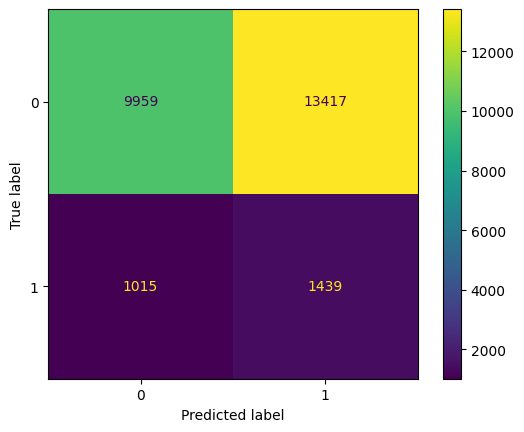

In [139]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

ConfusionMatrixDisplay(
    cm
).plot()

plt.show()

In [140]:
lr_f1 = f1_score(
    y_test,
    lr_pred
)

lr_aucpr = average_precision_score(
    y_test,
    lr_prob
)

print("F1:", lr_f1)

print("AUC-PR:", lr_aucpr)

F1: 0.16626227614095898
AUC-PR: 0.09897298656140129


In [141]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [142]:
rf.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [143]:
rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [144]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     23376
           1       0.56      0.71      0.63      2454

    accuracy                           0.92     25830
   macro avg       0.76      0.83      0.79     25830
weighted avg       0.93      0.92      0.92     25830



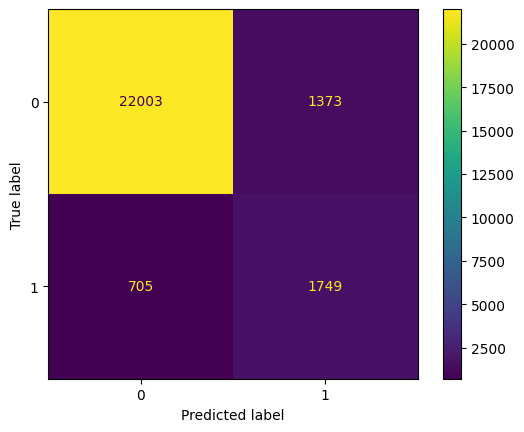

In [145]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

ConfusionMatrixDisplay(
    cm
).plot()

plt.show()

In [146]:
rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_aucpr = average_precision_score(
    y_test,
    rf_prob
)

print("F1:", rf_f1)

print("AUC-PR:", rf_aucpr)

F1: 0.6273314203730272
AUC-PR: 0.7235142001863362


In [147]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [148]:
rf_cv = cross_val_score(
    rf,
    X_train_smote,
    y_train_smote,
    cv=skf,
    scoring="f1"
)

In [149]:
print(
    "Mean:",
    rf_cv.mean()
)

print(
    "Std:",
    rf_cv.std()
)

Mean: 0.9062222320863962
Std: 0.0027413118336777355


In [150]:
results = pd.DataFrame(
    {
        "Model":[
            "Logistic Regression",
            "Random Forest"
        ],
        "F1":[
            lr_f1,
            rf_f1
        ],
        "AUC_PR":[
            lr_aucpr,
            rf_aucpr
        ]
    }
)

In [151]:
results

,Model,F1,AUC_PR
0,Logistic Regression,0.166262,0.098973
1,Random Forest,0.627331,0.723514


In [152]:
results.sort_values(
    "AUC_PR",
    ascending=False
)

,Model,F1,AUC_PR
1,Random Forest,0.627331,0.723514
0,Logistic Regression,0.166262,0.098973


In [153]:
best_model = rf

In [154]:
import os
import joblib

os.makedirs(
    "../models",
    exist_ok=True
)

In [155]:
joblib.dump(
    best_model,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

In [156]:
print("""
TASK 2 COMPLETE

✓ Train/Test Split
✓ SMOTE Applied
✓ Logistic Regression
✓ Random Forest
✓ Cross Validation
✓ Model Comparison
✓ Best Model Saved
""")


TASK 2 COMPLETE

✓ Train/Test Split
✓ SMOTE Applied
✓ Logistic Regression
✓ Random Forest
✓ Cross Validation
✓ Model Comparison
✓ Best Model Saved



In [158]:
try:
    print(type(lr_model))
except:
    print("lr_model not found")

try:
    print(type(rf_model))
except:
    print("rf_model not found")

try:
    print(type(best_model))
except:
    print("best_model not found")

lr_model not found
rf_model not found
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
